In [1]:
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Artifacts dir: D:\aie_repo\rusmina-ai-system\homeworks\HW06\artifacts


In [2]:
# Вспомогательные функции для эксперимента.

# Здесь нет “обучения” – только сервисные вещи:
# - compute_metrics: считает метрики (accuracy, F1, ROC-AUC при наличии вероятностей)
# - evaluate_on_test: единообразная оценка модели на тесте
# - save_json: аккуратное сохранение артефактов
# - plot_confusion / plot_roc: быстрая диагностика качества

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.savefig('artifacts/figures/confusion_matrix.png')
    plt.show()

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig('artifacts/figures/roc_curve.png')
    plt.show()

In [3]:
# Получили датасет, очистили от пустых значений
data = pd.read_csv("S06-hw-dataset-01.csv")

data.head()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [4]:
data.info() #  Получаем информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [5]:
# Размер датасета
print(data.shape[0]) # количество строк
print(data.shape[1]) # количество столбцов

12000
30


Как видим, преобразовывать данные к типам не нужно.

Применение базовых методов описательной статистики

In [6]:
data.describe()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


Подсчет доли пропусков в каждом столбце

In [7]:
data.isna().mean()

id               0.0
num01            0.0
num02            0.0
num03            0.0
num04            0.0
num05            0.0
num06            0.0
num07            0.0
num08            0.0
num09            0.0
num10            0.0
num11            0.0
num12            0.0
num13            0.0
num14            0.0
num15            0.0
num16            0.0
num17            0.0
num18            0.0
num19            0.0
num20            0.0
num21            0.0
num22            0.0
num23            0.0
num24            0.0
cat_contract     0.0
cat_region       0.0
cat_payment      0.0
tenure_months    0.0
target           0.0
dtype: float64

Проверим наличие дублирующих строк

In [8]:
df_dup = data.duplicated()
df_dup

0        False
1        False
2        False
3        False
4        False
         ...  
11995    False
11996    False
11997    False
11998    False
11999    False
Length: 12000, dtype: bool

In [9]:
sum(df_dup) #количество дубликатов

0

Как видим отсутствуют дублирующие строки и нулевые значения

Рассмотрим распределение таргета

In [10]:
target_distribution = data['target'].value_counts(normalize=True)
print(target_distribution)
print(f"\nАбсолютные значения:")
print(data['target'].value_counts())

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

Абсолютные значения:
target
0    8119
1    3881
Name: count, dtype: int64


Визуализируем распределение таргета

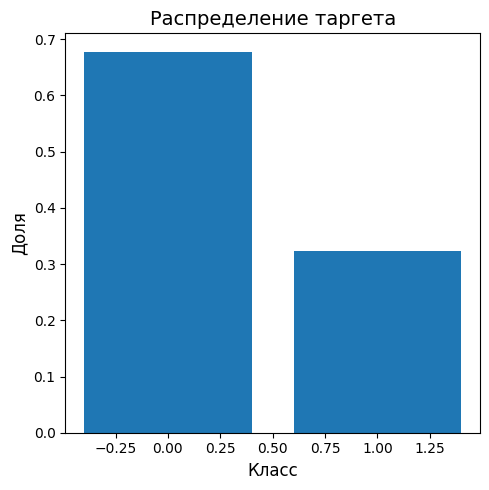

In [11]:
plt.figure(figsize=(5, 5))
bars = plt.bar(target_distribution.index, target_distribution.values)
plt.title('Распределение таргета', fontsize=14)
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Доля', fontsize=12)

plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1. Данные и фиксированное разбиение train/test

Ключевая идея: **разбиение фиксируется один раз** и дальше не меняется.  
Тогда любые различия в метриках объясняются моделями/гиперпараметрами, а не "удачным" разрезом данных.

**Важно:**

- используем `stratify=y`, чтобы доля классов в `train` и `test` была похожей;
- `random_state` фиксирует случайность, чтобы результаты можно было воспроизвести.

In [12]:
# Определение X и y
# Исключаем 'id' и 'target' из признаков
X = data.drop(['id', 'target'], axis=1)
y = data['target']
print("Название признаков")
print(list(X.columns))

Название признаков
['num01', 'num02', 'num03', 'num04', 'num05', 'num06', 'num07', 'num08', 'num09', 'num10', 'num11', 'num12', 'num13', 'num14', 'num15', 'num16', 'num17', 'num18', 'num19', 'num20', 'num21', 'num22', 'num23', 'num24', 'cat_contract', 'cat_region', 'cat_payment', 'tenure_months']


In [13]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=RANDOM_STATE,
    stratify=y  # Важно для сохранения распределения классов
)
X_train.shape, X_test.shape

((9000, 28), (3000, 28))

1. Фиксированный random_state (seed) важен для:
   - Воспроизводимости результатов
   - Сравнения разных моделей на одинаковых данных
   - Отладки и тестирования

2. Стратификация (stratify=y) важна для:
   - Сохранения пропорций классов в train и test наборах
   - Избежания несбалансированности в разбиениях
   - Корректной оценки моделей, особенно при дисбалансе классов

## 2. Baseline’ы

Baseline – это “точка отсчёта”. Если модель недели 6 не обгоняет baseline, то:

- либо она действительно не подходит под задачу,
- либо вы неправильно настроили эксперимент (например, переобучили/недообучили).

Здесь два baseline’а:

1) `DummyClassifier(most_frequent)` – простейшая нижняя планка (угадываем самый частый класс).  
2) `LogisticRegression` – сильный и быстрый baseline из прошлой недели (линейная модель + нормировка признаков).

Для `LogisticRegression` сделаем небольшой **подбор гиперпараметра `C`** на `train` через CV.


In [14]:
# Baseline'ы и подготовка контейнеров для результатов.

# - results: список словарей с метриками на тесте
# - best_models: сюда складываем обученные лучшие модели (чтобы потом их диагностировать/сохранить)
# - search_summaries: сюда складываем лучшие параметры подбора и CV-оценку

# CV = кросс-валидация на train: нужна для подбора гиперпараметров без доступа к тесту.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_models = {}  # label -> fitted best estimator
search_summaries = {}  # label -> краткая инфа о подборе

# 2.1 Dummy baseline (без подбора)

# Dummy baseline: помогает понять, что модель вообще умеет что-то лучше «угадайки».
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
results.append(evaluate_on_test(dummy, X_test, y_test, "Dummy(most_frequent)"))
best_models["Dummy(most_frequent)"] = dummy

# 2.2 LogisticRegression baseline (с минимальным подбором)

# Логрегрессия почти всегда требует масштабирования признаков, поэтому используем Pipeline со StandardScaler.
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])


# Подбираем C (обратная сила регуляризации): меньше C -> сильнее регуляризация -> проще модель.
lr_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"],
}


# GridSearchCV перебирает сетку параметров и оценивает качество по CV. scoring=roc_auc – метрика для бинарной классификации по вероятностям.
lr_search = GridSearchCV(
    lr, lr_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
best_models["LogReg(scaled)"] = best_lr

search_summaries["LogReg(scaled)"] = {
    "best_params": lr_search.best_params_,
    "best_cv_roc_auc": float(lr_search.best_score_),
}

results.append(evaluate_on_test(best_lr, X_test, y_test, "LogReg(scaled)"))

search_summaries["LogReg(scaled)"]
print(results)

[{'accuracy': 0.6766666666666666, 'f1': 0.0, 'roc_auc': 0.5, 'model': 'Dummy(most_frequent)'}, {'accuracy': 0.8296666666666667, 'f1': 0.7146845337800112, 'roc_auc': 0.878905083540704, 'model': 'LogReg(scaled)'}]


D:\aie_repo\rusmina-ai-system\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Результаты экспериментов
- Dummy Classifier (most_frequent):
  Accuracy: 67.67%
  F1-score: 0.0
  ROC-AUC: 0.5 (случайное угадывание)
- Logistic Regression со StandardScaler:
  Accuracy: 82.97%
  F1-score: 0.715
  ROC-AUC: 0.879

Ключевые наблюдения
1) Распределение классов:
   Dummy Classifier, предсказывающий самый частый класс, достигает accuracy 67.67%. Это означает, что в данных присутствует дисбаланс.
2) Эффективность Logistic Regression:
   Модель значительно превосходит baseline по всем метрикам. Улучшение accuracy: +15.3 процентных пункта (с 67.67% до 82.97%).
   F1-score: 0.715 показывает хороший баланс между precision и recall
   ROC-AUC = 0.879 соответствует хорошему качеству классификации

3) Интерпретация качества
   ROC-AUC = 0.879: Модель правильно ранжирует 87.9% пар объектов (положительный vs отрицательный класс)

## 3. Кандидаты недели 6: дерево, лес, бустинг

Сравним три семейства моделей:

- **Decision Tree** - простая нелинейность, быстро обучается, легко переобучается без ограничений.
- **Random Forest** - ансамбль деревьев, обычно устойчивее и сильнее одного дерева.
- **HistGradientBoosting** - градиентный бустинг (часто даёт высокое качество на табличных данных).

Протокол подбора:

- гиперпараметры подбираем через `GridSearchCV` **только на train**;
- метрику для подбора берём `roc_auc` (она хорошо работает для бинарной классификации, когда важна "сортировка" вероятностей);
- тест используем **ровно один раз** - для финальной честной оценки лучших моделей.

In [15]:
# Единая функция для подбора гиперпараметров через GridSearchCV.

# Она:
# - обучает GridSearchCV на X_train/y_train
# - кладёт лучшую модель и summary в словари
# - добавляет финальную оценку на тесте в results

def run_search(label: str, estimator, param_grid: dict):
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_roc_auc": float(search.best_score_),
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

In [16]:
# Decision Tree: одна модель дерева решений.

# Что обычно делает дерево “сложнее” и склоннее к переобучению:
# - большой max_depth
# - маленький min_samples_leaf
# ccp_alpha – параметр cost-complexity pruning (штраф за сложность).

# 3.1 Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 3, 5, 8],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

dt_search = run_search("DecisionTree", dt, dt_grid)
search_summaries["DecisionTree"]

{'best_params': {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 20},
 'best_cv_roc_auc': 0.9112358432907914}

In [17]:
# Random Forest: ансамбль деревьев (bagging).

# Идеи:
# - много деревьев (n_estimators) снижает дисперсию
# - max_features добавляет разнообразие деревьев (важно для ансамблей)
# - ограничения глубины/листа помогают контролировать переобучение

# 3.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False
)

rf_grid = {
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5],
}

rf_search = run_search("RandomForest", rf, rf_grid)
search_summaries["RandomForest"]

{'best_params': {'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1},
 'best_cv_roc_auc': 0.9684465802433795}

In [18]:
# HistGradientBoosting: градиентный бустинг по гистограммам (быстро и часто качественно).

# Ключевые “ручки”:
# - learning_rate: шаг обучения (меньше -> аккуратнее, часто нужно больше итераций)
# - max_depth / max_leaf_nodes: сложность базовых деревьев
# early_stopping=True включает остановку по внутренней валидации на train.

# 3.3 HistGradientBoosting (быстрый градиентный бустинг в sklearn)
hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True
)

hgb_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, None],
    "max_leaf_nodes": [15, 31, 63],
}

hgb_search = run_search("HistGradientBoosting", hgb, hgb_grid)
search_summaries["HistGradientBoosting"]

{'best_params': {'learning_rate': 0.1,
  'max_depth': None,
  'max_leaf_nodes': 63},
 'best_cv_roc_auc': 0.9719880531240899}

## 5. Сводка результатов (test)

Соберём все результаты в таблицу и отсортируем модели:

- сначала по `ROC‑AUC` (если он посчитан),
- иначе по `accuracy`.

Как читать метрики:

- **accuracy**: доля верных ответов (может быть “обманчивой” при сильном дисбалансе классов);
- **F1**: баланс точности и полноты для положительного класса;
- **ROC‑AUC**: качество ранжирования вероятностей (чем ближе к 1.0, тем лучше).


In [19]:
# Сводка результатов в таблицу.

# Обратите внимание:
# - ROC-AUC может быть None (если модель не выдаёт вероятности)
# - поэтому для сортировки создаём временный столбец roc_auc_sort

df = pd.DataFrame(results)

# сортировка: roc_auc (если есть) иначе accuracy
df_sorted = df.copy()
df_sorted["roc_auc_sort"] = df_sorted["roc_auc"].fillna(-1.0)
df_sorted = df_sorted.sort_values(["roc_auc_sort", "accuracy"], ascending=False).drop(columns=["roc_auc_sort"])

df_sorted

,accuracy,f1,roc_auc,model
4,0.936333,0.898242,0.974682,HistGradientBoosting
3,0.934667,0.894283,0.970610,RandomForest
2,0.863333,0.784890,0.910533,DecisionTree
1,0.829667,0.714685,0.878905,LogReg(scaled)
0,0.676667,0.000000,0.500000,Dummy(most_frequent)


Сохраним:

- финальную таблицу метрик на тесте;
- информацию о подборе (лучшие параметры и лучшая CV‑оценка).

Это делает эксперимент “закрытым циклом”: результаты есть и на экране, и в файлах.


In [20]:
# Сохранение артефактов эксперимента в artifacts/.

# После выполнения этой ячейки можно открыть папку artifacts/ и увидеть:
# - metrics_test.json (итоговые метрики)
# - search_summaries.json (лучшие параметры подбора)

metrics_path = ARTIFACTS_DIR / "metrics_test.json"
search_path = ARTIFACTS_DIR / "search_summaries.json"

save_json({"results": df_sorted.to_dict(orient="records")}, metrics_path)
save_json(search_summaries, search_path)

print("Saved:", metrics_path)
print("Saved:", search_path)

Saved: artifacts\metrics_test.json
Saved: artifacts\search_summaries.json


## 6. Лучшая модель: диагностика на тесте (confusion matrix + ROC)

После сортировки выберем “лучшую” модель (по `ROC‑AUC`, если он есть).

Дальше сделаем быструю диагностику:

- **confusion matrix** показывает, где именно модель ошибается (FP/FN);
- **ROC‑кривая** показывает качество ранжирования вероятностей по всем порогам.

Важно: это диагностика **после** всех подборов, на тесте. Мы не меняем модель по тесту – только оцениваем.


In [21]:
# Выбор “лучшей” модели по таблице результатов.

# Важно: мы НЕ переобучаем и не меняем модель по тесту.
# Мы только выбираем, какую модель будем диагностировать и сохранять.

best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('HistGradientBoosting',
 {'accuracy': 0.9363333333333334,
  'f1': 0.8982418753329782,
  'roc_auc': 0.9746823421867858,
  'model': 'HistGradientBoosting'})

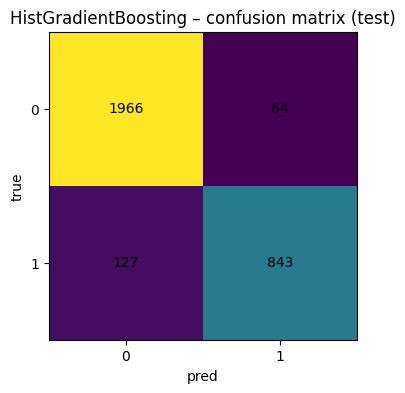

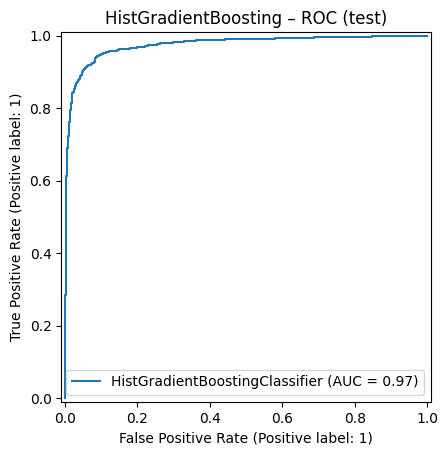

In [22]:
# Диагностика на тесте: confusion matrix и ROC-кривая.

# Confusion matrix помогает понять тип ошибок (FP/FN),
# ROC показывает качество ранжирования вероятностей по всем порогам.

y_pred = best_model.predict(X_test)
plot_confusion(y_test, y_pred, title=f"{best_label} – confusion matrix (test)")
plot_roc(best_model, X_test, y_test, title=f"{best_label} – ROC (test)")

## 7. Интерпретация: permutation importance (top‑15)

Permutation importance отвечает на вопрос:

> “Если случайно перемешать один признак, насколько сильно ухудшится качество модели?”

Если качество падает сильно – признак важен. Если почти не меняется – признак малозначим (для этой модели и этой метрики).

Ограничения метода:

- при сильной корреляции признаков важность “размазывается”;
- результат зависит от выбранной метрики (здесь `roc_auc` или `accuracy`);
- из‑за случайности (перемешивания) стоит делать несколько повторов (`n_repeats`).


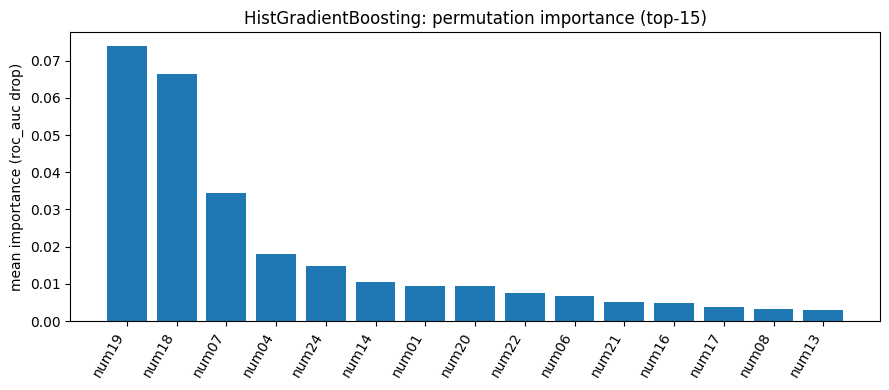

In [24]:
# Permutation importance на тесте (top-15)
scoring = "roc_auc" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring,
    n_jobs=-1
)

# Получаем важности и индексы
imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]
# Получаем названия признаков
feature_names = X_test.columns if hasattr(X_test, 'columns') else [f'Feature {i}' for i in range(X_test.shape[1])]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()
plt.savefig('artifacts/figures/permutation_importance.png')
plt.show()

## 8. Сохранение лучшей модели

Сохраним лучшую модель в `artifacts/best_model.joblib`.

Рядом положим `best_model_meta.json` – небольшой файл, где зафиксируем:

- какая именно модель оказалась лучшей;
- её метрики на тесте;
- результаты подбора гиперпараметров (если они были);
- `random_state`, чтобы было проще воспроизвести эксперимент.

In [25]:
# Сохранение лучшей модели и метаданных.

# - best_model.joblib: сериализованная модель
# - best_model_meta.json: “паспорт” результата (какая модель, какие метрики, какие параметры)

model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")

Saved: artifacts\best_model.joblib
Saved: artifacts\best_model_meta.json
